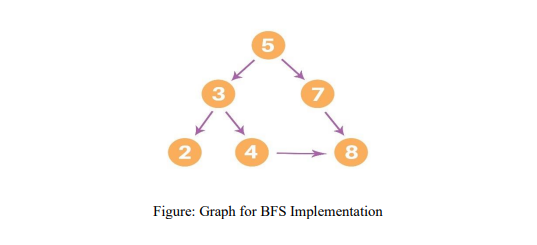

Following is the Breadth-First Search:
5 3 7 2 4 8 

Visualizing Graph Structure:


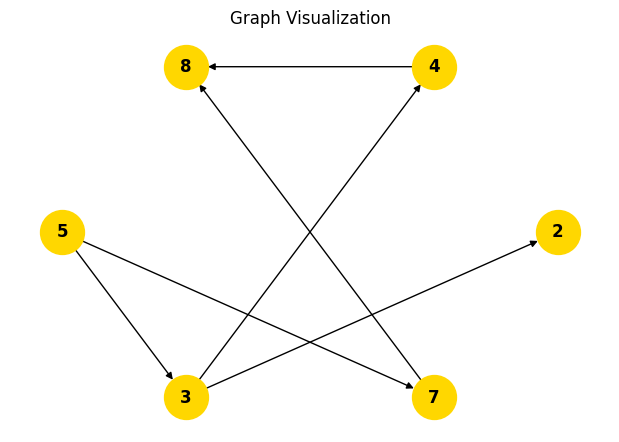

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Define the graph dictionary
# This matches your logic: 5 -> 3,7; 3 -> 2,4; 7 -> 8; 4 -> 8
graph = {
    '5' : ['3','7'],
    '3' : ['2', '4'],
    '7' : ['8'],
    '2' : [],
    '4' : ['8'],
    '8' : []
}

# 2. Setup variables for BFS
visited = [] # List for visited nodes
queue = []    # Initialize a queue

def bfs(visited, graph, node): # function for BFS
    visited.append(node)
    queue.append(node)

    while queue: # Creating loop to visit each node
        m = queue.pop(0)
        print(m, end = " ")

        for neighbour in graph[m]:
            if neighbour not in visited:
                visited.append(neighbour)
                queue.append(neighbour)

# 3. Driver Code
print("Following is the Breadth-First Search:")
bfs(visited, graph, '5')

# 4. Visualization Section
# This converts your dictionary into a visual chart
def plot_graph(graph_dict):
    G = nx.DiGraph()
    for node, neighbors in graph_dict.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    plt.figure(figsize=(6,4))
    pos = nx.shell_layout(G) # Arranges nodes in a readable way
    nx.draw(G, pos, with_labels=True, node_color='gold', node_size=1000, font_weight='bold', arrows=True)
    plt.title("Graph Visualization")
    plt.show()

print("\n\nVisualizing Graph Structure:")
plot_graph(graph)

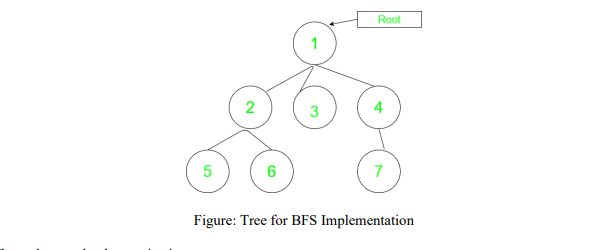

In [4]:

# Function to print the parent of each node
def printParents(node, adj, parent):
    # current node is Root, thus, has no parent
    if (parent == 0):
        print(node, "-> Root")
    else:
        print(node, "->", parent)

    # Using DFS to traverse and find parents
    for cur in adj[node]:
        if (cur != parent):
            printParents(cur, adj, node)

# Function to print the children of each node
def printChildren(Root, adj):
    # Queue for the BFS
    q = []
    q.append(Root)

    # visit array to keep track of nodes visited
    vis = [0] * len(adj)

    # BFS
    while (len(q) > 0):
        node = q[0]
        q.pop(0)
        vis[node] = 1
        print(node, "-> ", end=" ")
        for cur in adj[node]:
            if (vis[cur] == 0):
                print(cur, " ", end=" ")
                q.append(cur)
        print()

# Function to print the leaf nodes
def printLeafNodes(Root, adj):
    for i in range(1, len(adj)):
        # Leaf nodes have only one connection and are not the root
        if (len(adj[i]) == 1 and i != Root):
            print(i, end=" ")
    print()

# Function to print the degrees of each node
def printDegrees(Root, adj):
    for i in range(1, len(adj)):
        print(i, ": ", end=" ")
        # In a tree, degree is number of children
        if (i == Root):
            print(len(adj[i]))
        else:
            print(len(adj[i]) - 1)

# --- Driver code ---
N = 7
Root = 1
adj = [[] for _ in range(N + 1)]

# Creating the tree (undirected edges)
adj[1].append(2); adj[2].append(1)
adj[1].append(3); adj[3].append(1)
adj[1].append(4); adj[4].append(1)
adj[2].append(5); adj[5].append(2)
adj[2].append(6); adj[6].append(2)
adj[4].append(7); adj[7].append(4)

print("The parents of each node are:")
printParents(Root, adj, 0)

print("\nThe children of each node are:")
printChildren(Root, adj)

print("The leaf nodes of the tree are:")
printLeafNodes(Root, adj)

print("\nThe degrees of each node are:")
printDegrees(Root, adj)

The parents of each node are:
1 -> Root
2 -> 1
5 -> 2
6 -> 2
3 -> 1
4 -> 1
7 -> 4

The children of each node are:
1 ->  2   3   4   
2 ->  5   6   
3 ->  
4 ->  7   
5 ->  
6 ->  
7 ->  
The leaf nodes of the tree are:
3 5 6 7 

The degrees of each node are:
1 :  3
2 :  2
3 :  0
4 :  1
5 :  0
6 :  0
7 :  0


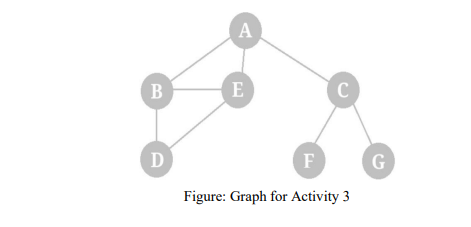

In [5]:
# Activity 3: BFS Implementation for Lab 04
# Step 1: Define the graph based on the Figure in Activity 3
# Format: 'Node': ['Neighbor1', 'Neighbor2']
graph = {
    'A' : ['B','C'],
    'B' : ['D', 'E'],
    'C' : ['F'],
    'D' : [],
    'E' : ['F'],
    'F' : []
}

# Step 2: Initialize lists for tracking
visited = [] # List for visited nodes.
queue = []    # Initialize a queue

# Step 3: Define the BFS function
def bfs(visited, graph, node):
    visited.append(node)
    queue.append(node)

    while queue:
        # Pop the first element (FIFO)
        m = queue.pop(0)
        print(m, end = " ")

        # Retrieve neighbors and add to queue if not visited
        for neighbour in graph[m]:
            if neighbour not in visited:
                visited.append(neighbour)
                queue.append(neighbour)

# Step 4: Driver Code
print("Following is the Breadth-First Search for Activity 3:")

# Replace 'A' with the starting node shown in your Figure
bfs(visited, graph, 'A')

Following is the Breadth-First Search for Activity 3:
A B C D E F 

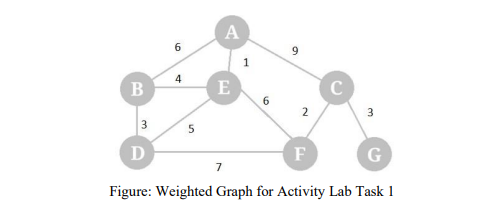

In [8]:
class Node:
    def __init__(self, state, parent, actions, total_cost):
        self.state = state
        self.parent = parent
        self.actions = actions
        self.total_cost = total_cost

# 1. Defining the Graph based on the image
# Structure: Node(State, Parent, [(Neighbor, Weight), ...], InitialCost)
graph = {
    'A': Node('A', None, [('B', 6), ('C', 9), ('E', 1)], 0),
    'B': Node('B', None, [('A', 6), ('D', 3), ('E', 4)], 0),
    'C': Node('C', None, [('A', 9), ('F', 2), ('G', 3)], 0),
    'D': Node('D', None, [('B', 3), ('E', 5), ('F', 7)], 0),
    'E': Node('E', None, [('A', 1), ('B', 4), ('D', 5), ('F', 6)], 0),
    'F': Node('F', None, [('C', 2), ('E', 6), ('D', 7)], 0),
    'G': Node('G', None, [('C', 3)], 0)
}

def bfs_with_cost(graph, start, goal):
    visited = []
    queue = []

    # Initialize start node
    start_node = graph[start]
    queue.append(start_node)
    visited.append(start)

    print(f"BFS Traversal starting from {start}:")

    while queue:
        current_node = queue.pop(0)
        print(f"Visiting: {current_node.state} (Total Cost so far: {current_node.total_cost})")

        # Check if we reached the goal
        if current_node.state == goal:
            print(f"\nGoal '{goal}' reached!")
            return current_node.total_cost

        # Explore neighbors (actions)
        for neighbor_state, weight in current_node.actions:
            if neighbor_state not in visited:
                visited.append(neighbor_state)

                # Update the neighbor node with parent and cumulative cost
                neighbor_node = graph[neighbor_state]
                neighbor_node.parent = current_node.state
                neighbor_node.total_cost = current_node.total_cost + weight

                queue.append(neighbor_node)

    return None

# --- Execution ---
start_state = 'A'
goal_state = 'G'
total_path_cost = bfs_with_cost(graph, start_state, goal_state)

print(f"Total path cost from {start_state} to {goal_state} using BFS: {total_path_cost}")

BFS Traversal starting from A:
Visiting: A (Total Cost so far: 0)
Visiting: B (Total Cost so far: 6)
Visiting: C (Total Cost so far: 9)
Visiting: E (Total Cost so far: 1)
Visiting: D (Total Cost so far: 9)
Visiting: F (Total Cost so far: 11)
Visiting: G (Total Cost so far: 12)

Goal 'G' reached!
Total path cost from A to G using BFS: 12


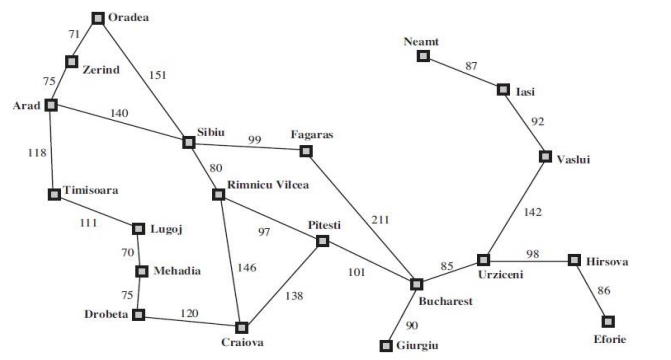

In [9]:
import collections

# 1. Defining the Romania Graph
graph = {
    'Arad': [('Zerind', 75), ('Sibiu', 140), ('Timisoara', 118)],
    'Zerind': [('Arad', 75), ('Oradea', 71)],
    'Oradea': [('Zerind', 71), ('Sibiu', 151)],
    'Sibiu': [('Arad', 140), ('Oradea', 151), ('Fagaras', 99), ('Rimnicu Vilcea', 80)],
    'Timisoara': [('Arad', 118), ('Lugoj', 111)],
    'Lugoj': [('Timisoara', 118), ('Mehadia', 70)],
    'Mehadia': [('Lugoj', 70), ('Drobeta', 75)],
    'Drobeta': [('Mehadia', 75), ('Craiova', 120)],
    'Craiova': [('Drobeta', 120), ('Rimnicu Vilcea', 146), ('Pitesti', 138)],
    'Rimnicu Vilcea': [('Sibiu', 80), ('Craiova', 146), ('Pitesti', 97)],
    'Fagaras': [('Sibiu', 99), ('Bucharest', 211)],
    'Pitesti': [('Rimnicu Vilcea', 97), ('Craiova', 138), ('Bucharest', 101)],
    'Bucharest': [('Fagaras', 211), ('Pitesti', 101), ('Giurgiu', 90), ('Urziceni', 85)]
}

def bfs_romania(graph, start, goal):
    # Queue stores (current_node, path_taken, total_distance)
    queue = collections.deque([(start, [start], 0)])
    visited = {start}

    while queue:
        (current, path, distance) = queue.popleft()

        if current == goal:
            return path, distance

        for (neighbor, weight) in graph.get(current, []):
            if neighbor not in visited:
                visited.add(neighbor)
                new_path = list(path)
                new_path.append(neighbor)
                queue.append((neighbor, new_path, distance + weight))

    return None, 0

# --- Execution ---
start_node = 'Arad'
goal_node = 'Bucharest'

path, total_distance = bfs_romania(graph, start_node, goal_node)

print("Following is the Breadth-First Search Path:")
print(" -> ".join(path))
print(f"\nTotal distance to reach {goal_node}: {total_distance} km")

Following is the Breadth-First Search Path:
Arad -> Sibiu -> Fagaras -> Bucharest

Total distance to reach Bucharest: 450 km
